In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt


# Define physical constant 
q = 1.602192e-19                # Elementary charge
epsilon0 = 8.854187817e-12      # Vaccum permittibity
nint = 1e10                     # Intrinsic carrier concentration
kB = 1.38065e-23                # Boltzmann constant
T = 300.0                       # Temperature
VT = kB*T/q                     # Thermal Voltage  

# Define Simulation variable  
a = 6e-9                        # Silicon Thickness  
tox = 0.5e-9                    # Oxide Thickness  
N = 20                          # Number of grid points 
l0 = a/N                        # Grid Spacing
iox = round(tox/l0)             # Oxide region index  
interface1 = iox                # Start of Silicon region  
interface2 = N-iox              # End of Silicon region

epsilon_si = 11.7               # Silicon Permittibity
epsilon_ox = 3.9                # Oxide Permittibity  

Ndop = -1e20                    # Dopant Concentration  

# Position vector  
x = np.arange(N+1)* a / N       # (N+1) Grid points 0 to a

x

array([0.0e+00, 3.0e-10, 6.0e-10, 9.0e-10, 1.2e-09, 1.5e-09, 1.8e-09,
       2.1e-09, 2.4e-09, 2.7e-09, 3.0e-09, 3.3e-09, 3.6e-09, 3.9e-09,
       4.2e-09, 4.5e-09, 4.8e-09, 5.1e-09, 5.4e-09, 5.7e-09, 6.0e-09])

In [15]:
# Initialize arrays  
phi = np.zeros( (N+1, 1  ) )        # Potential array
hole = np.zeros( (N+1, 1  ) )       # Hole density array
elec = np.zeros( (N+1, 1  ) )       # Electron density array  

# Intialize matrix & vector for solving Ax = b
A = np.zeros( (N+1, N+1) )          
b = np.zeros( (N+1, 1  ) )

# Intialize Gate Voltage-Electron density matrix
QV = np.zeros((11, 2))

QV

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [ ]:
# Gate voltage sweep
for ibias in range(0, 11):
    VG = 0.1 * ibias            # Gate voltage from 0.0 V to 1.0 V
    QV[ibias, 0] = VG           # Store gate voltage

    # Newton-Raphson Iteration loop  
    for inewton in range(1, 21):
        
        # Linear Possion Equation (Descretized form)
        for ii in range(1, N):
            epsilon_l = epsilon_ox
            epsilon_r = epsilon_ox

            # Permittibity Decision (Inside : Silicon, Outside : Oxide)
            if ii >= interface1 + 1 and ii <= interface2:
                epsilon_l = epsilon_si
            if ii >= interface1 and ii <= interface2 - 1:
                epsilon_r = epsilon_si

            # Discretized Poisson equation
            b[ii] = epsilon_r * (phi[ii+1] - phi[ii]) - epsilon_l * (phi[ii] - phi[ii-1])
            # Generate Laplacian matrix  
            A[ii, ii-1] = epsilon_l
            A[ii, ii] = -epsilon_l - epsilon_r
            A[ii, ii+1] = epsilon_r

        # Reset sheet density accumulator
        QV[ibias, 1] = 0.0  

        # Non-linear Possion Equation 
        for ii in range(interface1, interface2+1):
            control = 1.0
            if ii == interface1 or ii == interface2:
                control = 0.5  # Half-cell adjustment at interfaces

            # Hole & Electron Density Equation using Thermal Volgage 
            hole[ii] = nint * math.exp(-phi[ii]/VT)
            elec[ii] = nint * math.exp( phi[ii]/VT)

            # Update RHS vector
            b[ii] += q * (hole[ii] - elec[ii] + Ndop) / epsilon0 * l0**2 * control

            # Update Jacobian matrix 
            A[ii, ii] -= q * (hole[ii] + elec[ii]) / VT / epsilon0 * l0**2 * control

            # Accumulate sheet electron density
            QV[ibias, 1] += elec[ii] * l0 * control

        # Boundary Condition  
        b[0] = phi[0] - 0.33374 - VG
        A[0, 0] = 1
        b[N] = phi[N] - 0.33374 - VG
        A[N, N] = 1

        # Linear system solving & Update Potential value
        update = np.linalg.solve(A, b)
        phi = phi - update

        print(f"Iter{inewton} : phi = {phi}")

0.0
Iter1 : phi = [[0.33374   ]
 [0.33373967]
 [0.33373933]
 [0.33373923]
 [0.33373914]
 [0.33373906]
 [0.333739  ]
 [0.33373895]
 [0.33373891]
 [0.33373889]
 [0.33373889]
 [0.33373889]
 [0.33373891]
 [0.33373895]
 [0.333739  ]
 [0.33373906]
 [0.33373914]
 [0.33373923]
 [0.33373933]
 [0.33373967]
 [0.33374   ]]
Iter2 : phi = [[0.33374   ]
 [0.33373967]
 [0.33373933]
 [0.33373923]
 [0.33373914]
 [0.33373906]
 [0.333739  ]
 [0.33373895]
 [0.33373891]
 [0.33373889]
 [0.33373889]
 [0.33373889]
 [0.33373891]
 [0.33373895]
 [0.333739  ]
 [0.33373906]
 [0.33373914]
 [0.33373923]
 [0.33373933]
 [0.33373967]
 [0.33374   ]]
Iter3 : phi = [[0.33374   ]
 [0.33373967]
 [0.33373933]
 [0.33373923]
 [0.33373914]
 [0.33373906]
 [0.333739  ]
 [0.33373895]
 [0.33373891]
 [0.33373889]
 [0.33373889]
 [0.33373889]
 [0.33373891]
 [0.33373895]
 [0.333739  ]
 [0.33373906]
 [0.33373914]
 [0.33373923]
 [0.33373933]
 [0.33373967]
 [0.33374   ]]
Iter4 : phi = [[0.33374   ]
 [0.33373967]
 [0.33373933]
 [0.33373923]

C:\Users\isang\AppData\Local\Temp\ipykernel_34536\3672138500.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hole[ii] = nint * math.exp(-phi[ii]/VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_34536\3672138500.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  elec[ii] = nint * math.exp( phi[ii]/VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_34536\3672138500.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[ii, ii] -= q * (hole[ii] + elec[ii]) / VT / e

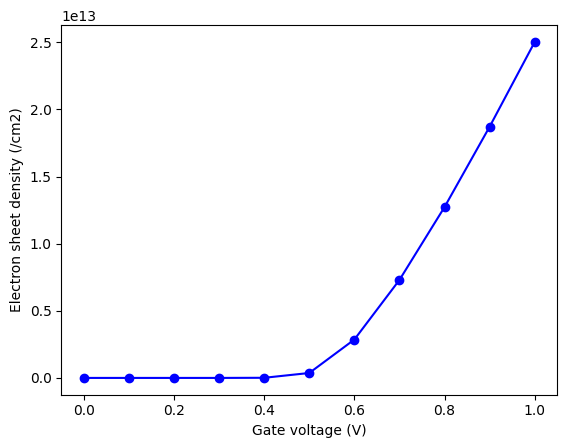

In [17]:
plt.plot(QV[:,0],QV[:,1]/1e4,'bo-')

plt.xlabel('Gate voltage (V)')
plt.ylabel('Electron sheet density (/cm2)')

plt.show()